In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("Fish_dataset.csv")

In [3]:
data.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [5]:
data.shape

(159, 7)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [7]:
data.isnull().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [8]:
import matplotlib.pyplot as plt

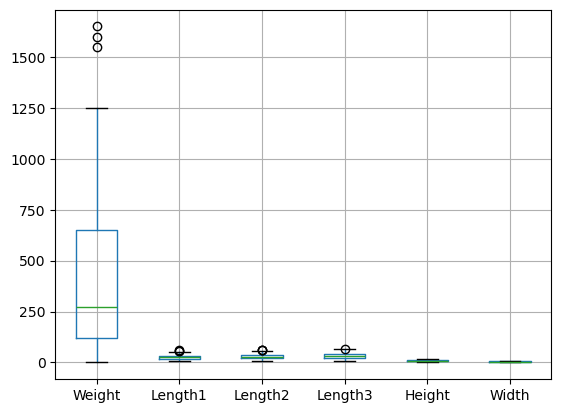

In [9]:
boxplot = data.boxplot(column=['Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width'])

In [13]:
data['Species'].value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In [14]:
colname=[]
for x in data.columns:
    if data[x].dtypes=='object':
        colname.append(x)
colname

['Species']

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for x in colname:
    data[x] = le.fit_transform(data[x])

    le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print('Feature', x)
    print('Mapping', le_name_mapping)



Feature Species
Mapping {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(5): np.int64(5), np.int64(6): np.int64(6)}


In [18]:
X = data[['Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']]
Y = data['Species']

In [19]:
X.shape

(159, 6)

In [20]:
Y.shape

(159,)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X)
X_scaled = scaler.transform(X)

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=10)

In [25]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(127, 6)
(32, 6)
(127,)
(32,)


In [26]:
from sklearn.neighbors import KNeighborsClassifier
model_KNN = KNeighborsClassifier(n_neighbors=int(np.sqrt(len(X_train))),
                                 metric='euclidean')

In [27]:
model_KNN.fit(X_train, Y_train)

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [29]:
Y_pred = model_KNN.predict(X_test)
print(list(zip(Y_test, Y_pred)))

[(4, np.int64(2)), (2, np.int64(2)), (4, np.int64(4)), (0, np.int64(0)), (3, np.int64(2)), (2, np.int64(4)), (3, np.int64(2)), (0, np.int64(0)), (6, np.int64(0)), (2, np.int64(2)), (1, np.int64(2)), (1, np.int64(2)), (4, np.int64(2)), (0, np.int64(0)), (4, np.int64(2)), (5, np.int64(5)), (2, np.int64(2)), (0, np.int64(2)), (1, np.int64(4)), (2, np.int64(2)), (0, np.int64(0)), (2, np.int64(2)), (5, np.int64(5)), (2, np.int64(2)), (0, np.int64(0)), (4, np.int64(2)), (2, np.int64(2)), (6, np.int64(2)), (3, np.int64(0)), (5, np.int64(5)), (2, np.int64(2)), (1, np.int64(2))]


In [30]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm = confusion_matrix(Y_test, Y_pred)
print(cfm)

print("Classification Report: ")
print(classification_report(Y_test, Y_pred))

acc= accuracy_score(Y_test, Y_pred)
print("Accuracy: ", acc)

[[5 0 1 0 0 0 0]
 [0 0 3 0 1 0 0]
 [0 0 8 0 1 0 0]
 [1 0 2 0 0 0 0]
 [0 0 4 0 1 0 0]
 [0 0 0 0 0 3 0]
 [1 0 1 0 0 0 0]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.71      0.83      0.77         6
           1       0.00      0.00      0.00         4
           2       0.42      0.89      0.57         9
           3       0.00      0.00      0.00         3
           4       0.33      0.20      0.25         5
           5       1.00      1.00      1.00         3
           6       0.00      0.00      0.00         2

    accuracy                           0.53        32
   macro avg       0.35      0.42      0.37        32
weighted avg       0.40      0.53      0.44        32

Accuracy:  0.53125


c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [32]:
data.to_csv("6_KNN_Fish_dataset.csv", index=False)